# 03 — Statistical Analysis

**Purpose:** validate and understand the important statistical patterns found during EDA.

This notebook uses descriptive statistics and association measures. It does not estimate causal effects, run experiments, build predictive models, or repeat the full set of EDA charts.

## Setup

**Business question:** Which district snapshot is used for the statistical review?

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from phonepe_analytics.analysis import ANALYSIS_DIR

purple = "#5F259F"
blue = "#2F6BFF"
green = "#2A9D6F"
orange = "#F28E2B"

district_data = pd.read_csv(ANALYSIS_DIR / "district_metrics.csv")
latest_period_id = district_data["period_id"].max()
latest_districts = district_data.loc[
    district_data["period_id"].eq(latest_period_id)
].copy()
latest_districts["growth_gap"] = (
    latest_districts["user_qoq"]
    - latest_districts["merchant_qoq"]
)
latest_period = latest_districts["period_label"].iloc[0]

display(
    pd.DataFrame(
        {
            "analysis_period": [latest_period],
            "districts": [len(latest_districts)],
        }
    )
)

,analysis_period,districts
0,2026-Q2,783


### Insight

- **What the data shows:** The review uses all **783 districts** from the **2026-Q2** snapshot.

- **Why it matters:** Keeping the same population makes the EDA and statistical results directly comparable.

- **Merchant-expansion implication:** Eligibility filters should be applied later during opportunity ranking, not during this diagnostic review.

## 1. Distribution Summary

**Business question:** How skewed and variable are the main district measures?

In [2]:
distribution_metrics = [
    "transaction_count",
    "transaction_amount",
    "registered_users",
    "registered_merchants",
    "merchants_per_100k_users",
    "transaction_yoy",
    "growth_gap",
]

distribution_summary = latest_districts[
    distribution_metrics
].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
).T
distribution_summary = distribution_summary.rename(
    columns={"50%": "median"}
)
distribution_summary["iqr"] = (
    distribution_summary["75%"] - distribution_summary["25%"]
)
distribution_summary["skewness"] = latest_districts[
    distribution_metrics
].skew()
distribution_summary = distribution_summary[
    [
        "count",
        "mean",
        "median",
        "std",
        "25%",
        "75%",
        "iqr",
        "90%",
        "95%",
        "skewness",
    ]
]

display(distribution_summary.round(3))

,count,mean,median,std,25%,75%,iqr,90%,95%,skewness
transaction_count,783.0,4.937968e+07,2.444644e+07,1.111778e+08,7.906492e+06,5.737864e+07,4.947215e+07,9.977271e+07,1.414877e+08,11.013
transaction_amount,783.0,5.810530e+10,2.949028e+10,1.197750e+11,9.090879e+09,6.739149e+10,5.830062e+10,1.310549e+11,1.906250e+11,10.249
registered_users,783.0,9.088803e+05,6.113150e+05,1.341768e+06,2.574440e+05,1.101086e+06,8.436420e+05,1.817077e+06,2.606995e+06,6.914
registered_merchants,783.0,6.475766e+04,3.885400e+04,1.084056e+05,1.341400e+04,7.465400e+04,6.124000e+04,1.374402e+05,1.936286e+05,6.679
merchants_per_100k_users,783.0,5.976175e+03,6.139588e+03,2.397867e+03,4.530877e+03,7.609214e+03,3.078337e+03,8.878458e+03,9.510450e+03,-0.263
transaction_yoy,783.0,2.610000e-01,2.530000e-01,1.580000e-01,2.080000e-01,2.980000e-01,9.100000e-02,3.400000e-01,3.780000e-01,15.829
growth_gap,783.0,-8.000000e-03,-0.000000e+00,7.500000e-02,-1.300000e-02,1.100000e-02,2.300000e-02,2.200000e-02,3.000000e-02,-10.047


### Insight

- **What the data shows:** Transaction count has a mean of **49,379,675**, a median of **24,446,442**, and skewness of **11.01**; user counts show the same mean-median gap.

- **Why it matters:** The large positive skew means raw averages are strongly influenced by a few major districts.

- **Merchant-expansion implication:** Use medians and percentile ranks to compare districts fairly in the opportunity score.

## 2. Outlier Analysis

**Business question:** Which observations are unusual under the IQR rule?

,metric,lower_bound,upper_bound,outlier_count,outlier_percentage,full_mean,median
0,transaction_count,-6.630173e+07,1.315869e+08,49,6.258,4.937968e+07,2.444644e+07
1,registered_users,-1.008019e+06,2.366549e+06,48,6.130,9.088803e+05,6.113150e+05
2,merchants_per_100k_users,-8.662900e+01,1.222672e+04,3,0.383,5.976175e+03,6.139588e+03
3,transaction_yoy,7.200000e-02,4.340000e-01,37,4.725,2.610000e-01,2.530000e-01


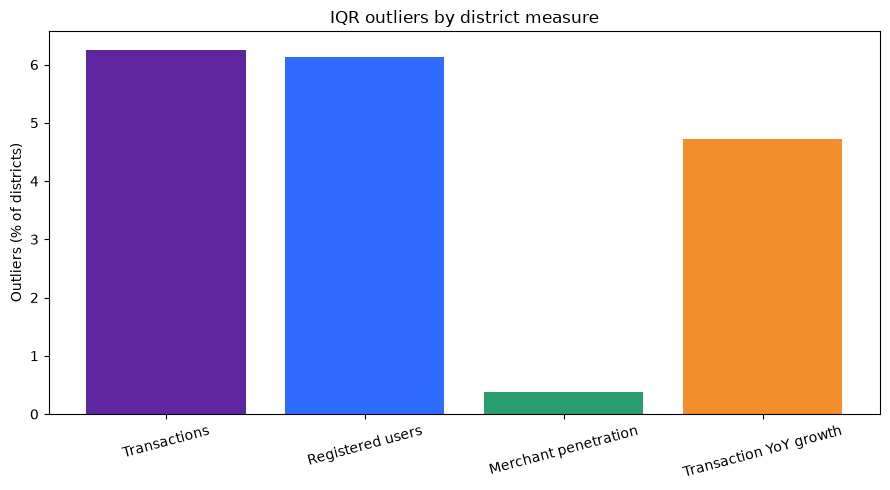

In [3]:
outlier_metrics = [
    "transaction_count",
    "registered_users",
    "merchants_per_100k_users",
    "transaction_yoy",
]

outlier_rows = []

for metric in outlier_metrics:
    values = latest_districts[metric].dropna()
    first_quartile = values.quantile(0.25)
    third_quartile = values.quantile(0.75)
    iqr = third_quartile - first_quartile
    lower_bound = first_quartile - 1.5 * iqr
    upper_bound = third_quartile + 1.5 * iqr
    is_outlier = values.lt(lower_bound) | values.gt(upper_bound)

    outlier_rows.append(
        {
            "metric": metric,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": int(is_outlier.sum()),
            "outlier_percentage": is_outlier.mean() * 100,
            "full_mean": values.mean(),
            "median": values.median(),
        }
    )

outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary.round(3))

outlier_chart = outlier_summary.copy()
outlier_chart["metric"] = outlier_chart["metric"].replace(
    {
        "transaction_count": "Transactions",
        "registered_users": "Registered users",
        "merchants_per_100k_users": "Merchant penetration",
        "transaction_yoy": "Transaction YoY growth",
    }
)
fig, axis = plt.subplots(figsize=(9, 5))
axis.bar(
    outlier_chart["metric"],
    outlier_chart["outlier_percentage"],
    color=[purple, blue, green, orange],
)
axis.set_title("IQR outliers by district measure")
axis.set_xlabel("")
axis.set_ylabel("Outliers (% of districts)")
axis.tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.show()

In [4]:
high_volume_districts = latest_districts.nlargest(
    8,
    "transaction_count",
)[
    [
        "state",
        "district",
        "transaction_count",
        "registered_users",
        "registered_merchants",
        "transaction_yoy",
    ]
]

display(high_volume_districts.reset_index(drop=True))

,state,district,transaction_count,registered_users,registered_merchants,transaction_yoy
0,karnataka,bengaluru urban,2.113433e+09,20543058,1517644.0,0.173172
1,maharashtra,pune,1.190116e+09,14753740,1261805.0,0.230502
2,telangana,rangareddy,8.453297e+08,7229570,452117.0,0.254740
3,telangana,medchal malkajgiri,7.590408e+08,6313836,455298.0,0.240344
4,rajasthan,jaipur,6.372599e+08,7999367,813696.0,0.159128
5,telangana,hyderabad,5.720922e+08,5840094,433462.0,0.213475
6,uttar pradesh,gautambuddha nagar,4.314158e+08,5609621,426703.0,0.217466
7,haryana,gurugram,4.052013e+08,5282943,357594.0,0.195865


### Insight

- **What the data shows:** The IQR rule flags **49 transaction-count**, **48 user**, **3 penetration**, and **37 growth** outliers.

- **Why it matters:** Many extremes are major markets or genuinely fast-growing districts, so unusual values are not automatically data errors.

- **Merchant-expansion implication:** Retain valid extremes and use percentile normalization to limit their influence.

## 3. Correlation Method Selection

**Business question:** Which correlation method fits these skewed district measures?

| Method | Appropriate use | Decision for this project |
|---|---|---|
| **Spearman correlation** | Measures whether two variables move in a consistent ranked direction. It is less sensitive to long tails and extreme values. | Primary method because district scale and growth measures are skewed and contain genuine outliers. |
| **Pearson correlation** | Measures a linear relationship and is most useful when extreme values do not dominate the pattern. | Not used as the primary result because the main variables are strongly skewed and several relationships are nonlinear on their original scale. |

Correlation measures association only. It cannot establish that adding merchants causes more transactions or that transactions cause merchant registrations.

### Method decision

- **What the data shows:** The key variables are skewed and contain valid extreme values.

- **Why it matters:** Spearman correlation compares ranked movement and is less sensitive to those extremes than Pearson correlation.

- **Merchant-expansion implication:** Use Spearman as the primary association measure and do not interpret correlation as causation.

## 4. Important Correlations

**Business question:** How strongly are the main scale, coverage, and growth variables associated?

,relationship,spearman_correlation,direction,strength,business_interpretation
0,User scale vs transaction demand,0.933,Positive,Strong,Shows whether larger registered-user bases als...
1,Merchant scale vs transaction demand,0.904,Positive,Strong,Shows whether larger merchant-registration bas...
2,Merchant penetration vs transaction growth,0.108,Positive,Weak,Tests whether relative merchant density aligns...
3,User growth vs merchant growth,0.127,Positive,Weak,Checks whether registration growth moves toget...


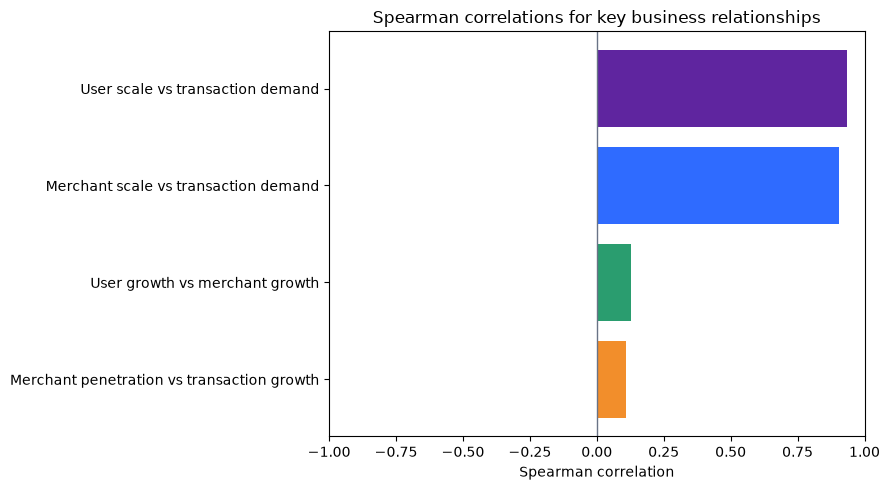

In [5]:
correlation_pairs = [
    (
        "registered_users",
        "transaction_count",
        "User scale vs transaction demand",
        "Shows whether larger registered-user bases also rank higher in activity.",
    ),
    (
        "registered_merchants",
        "transaction_count",
        "Merchant scale vs transaction demand",
        "Shows whether larger merchant-registration bases align with activity.",
    ),
    (
        "merchants_per_100k_users",
        "transaction_yoy",
        "Merchant penetration vs transaction growth",
        "Tests whether relative merchant density aligns with demand growth.",
    ),
    (
        "user_qoq",
        "merchant_qoq",
        "User growth vs merchant growth",
        "Checks whether registration growth moves together across districts.",
    ),
]

correlation_rows = []

for x_column, y_column, relationship, interpretation in correlation_pairs:
    correlation = latest_districts[[x_column, y_column]].corr(
        method="spearman"
    ).iloc[0, 1]
    absolute_correlation = abs(correlation)

    if absolute_correlation >= 0.70:
        strength = "Strong"
    elif absolute_correlation >= 0.40:
        strength = "Moderate"
    else:
        strength = "Weak"

    direction = "Positive" if correlation >= 0 else "Negative"

    correlation_rows.append(
        {
            "relationship": relationship,
            "spearman_correlation": correlation,
            "direction": direction,
            "strength": strength,
            "business_interpretation": interpretation,
        }
    )

important_correlations = pd.DataFrame(correlation_rows)
display(important_correlations.round(3))

correlation_chart = important_correlations.sort_values(
    "spearman_correlation"
)
fig, axis = plt.subplots(figsize=(9, 5))
axis.barh(
    correlation_chart["relationship"],
    correlation_chart["spearman_correlation"],
    color=[orange, green, blue, purple],
)
axis.axvline(0, color="#697386", linewidth=1)
axis.set_xlim(-1, 1)
axis.set_title("Spearman correlations for key business relationships")
axis.set_xlabel("Spearman correlation")
axis.set_ylabel("")
fig.tight_layout()
plt.show()

### Insight

- **What the data shows:** Users versus transactions is **0.933** and merchants versus transactions is **0.904**; penetration versus growth is only **0.108**, and user versus merchant growth is **0.127**.

- **Why it matters:** Scale variables overlap strongly, while penetration and growth contribute more distinct information.

- **Merchant-expansion implication:** Control the combined weight of scale variables and retain growth and penetration as complementary score inputs.

## 5. Statistical Findings

**Business question:** What statistical choices should guide the opportunity analysis?

1. **Use robust comparisons.** Transaction counts and registered users are strongly right-skewed, so medians and percentile ranks describe district position more reliably than raw means.

2. **Retain genuine extremes.** The IQR method flags **49 high- or low-volume transaction outliers**. Several represent major markets, so removing them automatically would discard important commercial scale.

3. **Avoid duplicate scale signals.** Registered users and transactions have a correlation of **0.933**. Heavy weights on both could allow market size to dominate the Opportunity Score.

4. **Treat penetration as a complementary factor.** Merchant penetration and transaction growth correlate at only **0.108**. Combining demand, growth, user scale, and penetration is more defensible than ranking on one ratio.

5. **Interpret growth gaps cautiously.** User and merchant registration growth do not move in perfect lockstep. Their difference can highlight districts for investigation, but aggregate registrations cannot establish active demand, merchant shortage, or causal impact.

These findings support transparent percentile normalization, limited use of overlapping measures, retention of outliers, and sensitivity testing in Notebook 04.